# Chapter 9 — The Core Math of Self-Attention

Chapter 8 ended on a promise:

> The natural next step is **attention**, the mechanism that carries text
> conditioning into the U-Net, and the one architectural idea in modern
> generative AI you have not yet built from scratch.

This is that step. **Start with a single matrix expression.** Every Transformer
ever trained is a stack of this one operation, interleaved with ordinary MLPs:

$$ \text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V $$

Nothing in the chapters that follow changes that expression. What changes is
what you feed it: words here, then image patches, then noisy latents.

| Module | What you build | Dataset (Hugging Face) |
|---|---|---|
| 1 | The problem: why convolution and recurrence cannot reach across a sequence | `stanfordnlp/imdb` |
| 2 | **$Q$, $K$, $V$** by hand: three matrix multiplies, shapes checked at every step | — |
| 3 | **Scaled dot-product attention**, including an experiment showing what $\sqrt{d_k}$ actually rescues | — |
| 4 | A trained single-head attention classifier, and its **attention heatmap** | `stanfordnlp/imdb` |
| 5 | **Masking**: padding masks, and the causal mask that makes generation possible | — |
| 6 | The $O(n^2)$ bill, and what the field does about it | — |

**How each concept is presented**, the same three passes as earlier chapters:

> 🧠 **The intuition:** the idea in plain language, no symbols.
> 📐 **The math:** the same idea written precisely, so you can read papers.
> 💻 **The code:** the same idea again, executable, in the cell that follows.

---

### ⚠️ A framework change: Keras → PyTorch

Chapters 1–8 were Keras. This one is **PyTorch**, and the switch is deliberate
rather than cosmetic:

- **The tooling for this specific topic is PyTorch-only.** Hugging Face
  `transformers` dropped TensorFlow support in v5; `diffusers` never had it.
  The reference implementations of the Diffusion Transformer
  (`facebookresearch/DiT`), SD3 and Flux are all PyTorch. From here on, the
  code you would read next is torch, so writing torch means you can diff your
  work against the real thing.
- **It is what industry trains in.** Keras 3 is a good API, but it is a wrapper
  choice; torch is the substrate underneath most of what ships.

The mental model transfers directly. `keras.layers.Layer` → `nn.Module`,
`build()`/`call()` → `__init__()`/`forward()`. The one genuine difference is
that **PyTorch has no `model.fit()`**, so you write the training loop yourself:
zero the gradients, forward, loss, backward, step. You will see that loop in
Module 4, and it will look a lot like the two-tape GAN loop from Chapter 7,
minus the adversary.

**Runtime:** well under a minute on a GPU, where the Module 4 training run is
about 15 seconds and everything else is small matrices and plots. IMDB is an
~80 MB download on first run, then cached.


In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from transformers import AutoTokenizer

torch.manual_seed(42)
rng = np.random.default_rng(seed=42)
plt.rcParams["figure.figsize"] = (7, 4.5)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch", torch.__version__, "| device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0),
          "| sm_%d%d" % torch.cuda.get_device_capability(0))
else:
    print("CPU only, so everything still runs; Module 4 just takes ~5x longer")

/home/mujtaba/venvs/datasci/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.11.0+cu128 | device: cuda
GPU: NVIDIA GeForce RTX 5090 | sm_120


---
# Module 1 — The Problem: Distance

## 1.1 Everything you have built so far is local

🧠 **The intuition.** A 3×3 convolution looks at nine pixels. Stack two and the
receptive field is 5×5; stack three and it is 7×7. To connect two pixels on
opposite corners of a 32×32 image, you need roughly fifteen layers, or
aggressive downsampling, which is exactly what the U-Net's bottleneck was doing
in Chapter 8. Convolution buys **locality**, and locality is a genuinely good
prior for images, but it means long-range relationships are something the
network has to *construct* through depth rather than something it can simply
*look up*.

Recurrence (RNNs, LSTMs) has the opposite problem. It can in principle connect
position 1 to position 500, but only by passing information through 499
intermediate states, one at a time. That is slow, with no parallelism across the
sequence, and the gradient has to survive 499 multiplications on the way back,
which is the vanishing-gradient problem you measured in Chapter 3, in its most
severe form.

**Self-attention makes the path length 1.** Every position can read from every
other position in a single operation, in parallel. That is the whole pitch.

📐 **The math.** The relevant quantity is the **maximum path length**: the
number of sequential operations a signal must traverse to get from any input
position to any output position. From "Attention Is All You Need" (Vaswani et
al., 2017), for a sequence of length $n$ with representation width $d$ and
convolution kernel size $k$:

| Layer type | Complexity per layer | Sequential ops | Max path length |
|---|---|---|---|
| Recurrent | $O(n \cdot d^2)$ | $O(n)$ | $O(n)$ |
| Convolutional (stacked, kernel $k$) | $O(k \cdot n \cdot d^2)$ | $O(1)$ | $O(n/k)$ |
| Convolutional (dilated) | $O(k \cdot n \cdot d^2)$ | $O(1)$ | $O(\log_k n)$ |
| **Self-attention** | $O(n^2 \cdot d)$ | $O(1)$ | $\mathbf{O(1)}$ |

Read the last column, then read the first. Attention buys a constant path
length, and the price is written right there in the complexity term: $n^2$. We
will pay that bill explicitly in Module 6.

💻 **The code.** First, a sequence that makes the problem concrete.


In [2]:
imdb = load_dataset("stanfordnlp/imdb")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

print(imdb)
print("\nvocab size:", tokenizer.vocab_size)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

vocab size: 30522


Here is why distance matters, in one pair of sentences. They share almost every
word; the sentiment is opposite; and the word that decides it sits far from the
words it modifies.

In [3]:
pair = [
    "the plot was predictable and the acting wooden , but i loved every minute of it",
    "the plot was inventive and the acting superb , but i hated every minute of it",
]

gaps = []
for s in pair:
    ids = tokenizer(s, add_special_tokens=False)["input_ids"]
    toks = tokenizer.convert_ids_to_tokens(ids)
    verdict = "loved" if "loved" in toks else "hated"
    i_verdict = toks.index(verdict)
    i_first = min(toks.index(w) for w in ("predictable", "in") if w in toks)
    gaps.append(i_verdict - i_first)
    print(f"{len(toks):>3} tokens | {toks}")
    print(f"      '{verdict}' sits at position {i_verdict}, {i_verdict - i_first} "
          f"positions after the description it overrules\n")

gap = min(gaps)
print(f"Opposite sentiment from nearly identical words, decided {gap} tokens away.")
print(f"To let those two positions interact, each architecture needs:")
# a kernel-3 conv grows its receptive-field radius by 1 per layer
print(f"  a 3x3 conv stack   : {gap} layers (radius grows by 1 each layer)")
print(f"  an RNN             : {gap} sequential steps, and {gap} multiplications on the")
print(f"                       gradient's way back, the vanishing-gradient path")
print(f"  self-attention     : 1 step, in parallel, regardless of the distance")

 16 tokens | ['the', 'plot', 'was', 'predictable', 'and', 'the', 'acting', 'wooden', ',', 'but', 'i', 'loved', 'every', 'minute', 'of', 'it']
      'loved' sits at position 11, 8 positions after the description it overrules

 18 tokens | ['the', 'plot', 'was', 'in', '##vent', '##ive', 'and', 'the', 'acting', 'superb', ',', 'but', 'i', 'hated', 'every', 'minute', 'of', 'it']
      'hated' sits at position 13, 10 positions after the description it overrules

Opposite sentiment from nearly identical words, decided 8 tokens away.
To let those two positions interact, each architecture needs:
  a 3x3 conv stack   : 8 layers (radius grows by 1 each layer)
  an RNN             : 8 sequential steps, and 8 multiplications on the
                       gradient's way back, the vanishing-gradient path
  self-attention     : 1 step, in parallel, regardless of the distance


---
# Module 2 — $Q$, $K$, $V$: Three Projections of the Same Thing

## 2.1 The party

🧠 **The intuition.** Picture a crowded room where everyone needs information
from everyone else, and nobody knows in advance who has what.

The protocol is this. Each person broadcasts two things: a **query** ("I am an
adjective and I am looking for the noun I modify") and a **key** ("I am a noun,
here is my identity"). Everyone compares their own query against everyone
else's key, and the pairs that match well pay attention to each other. What
actually gets passed along, though, is a third thing: the **value**, the
content itself, which is deliberately kept separate from the addressing scheme.

That separation is the design insight, and it is worth pausing on. *How
relevant is this token to me* and *what does this token actually contain* are
different questions, so they get different learned projections. A word can be
easy to find and carry little, or vice versa.

📐 **The math.** Start with the token embeddings $X \in \mathbb{R}^{n \times
d_{\text{model}}}$, meaning $n$ tokens, each a $d_{\text{model}}$-dimensional
vector. Three learned weight matrices produce the three roles:

$$ Q = X W_Q, \qquad K = X W_K, \qquad V = X W_V $$

with $W_Q, W_K \in \mathbb{R}^{d_{\text{model}} \times d_k}$ and $W_V \in
\mathbb{R}^{d_{\text{model}} \times d_v}$. These three matrices are the *only*
parameters in an attention layer besides the output projection. Everything else
(the comparisons, the softmax, the weighted sum) is fixed arithmetic with
nothing to learn.

Note that all three come from the **same** $X$. That is what makes it
*self*-attention: the sequence is querying itself. Change exactly one thing,
letting $K$ and $V$ come from a *different* sequence, and you get
**cross-attention**, which is how a text prompt steers an image model.

💻 **The code.** Embed the sentence, then project it three ways. Watch the
shapes; they are the whole story.


In [4]:
D_MODEL = 32          # <- knob: embedding width. Real models: 768 (BERT), 4096+ (LLMs)
D_K = 32              # <- knob: query/key width. Equal to d_model for a single head

sentence = pair[0]
ids = tokenizer(sentence, add_special_tokens=False)["input_ids"]
tokens = tokenizer.convert_ids_to_tokens(ids)
n = len(ids)

# A random (untrained) embedding table, so we can watch the arithmetic before
# any learning has happened.
embed = nn.Embedding(tokenizer.vocab_size, D_MODEL)
X = embed(torch.tensor(ids))                       # (n, d_model)

W_Q = nn.Linear(D_MODEL, D_K, bias=False)
W_K = nn.Linear(D_MODEL, D_K, bias=False)
W_V = nn.Linear(D_MODEL, D_K, bias=False)

Q = W_Q(X)                                          # (n, d_k)  "what am I looking for"
K = W_K(X)                                          # (n, d_k)  "what do I contain, as an address"
V = W_V(X)                                          # (n, d_v)  "what do I contain, as content"

print(f"sequence           : {n} tokens")
print(f"X   (embeddings)   : {tuple(X.shape)}")
print(f"Q = X W_Q          : {tuple(Q.shape)}")
print(f"K = X W_K          : {tuple(K.shape)}")
print(f"V = X W_V          : {tuple(V.shape)}")
print(f"\nlearnable params in this layer: {3 * D_MODEL * D_K:,}  (three {D_MODEL}x{D_K} matrices)")

sequence           : 16 tokens
X   (embeddings)   : (16, 32)
Q = X W_Q          : (16, 32)
K = X W_K          : (16, 32)
V = X W_V          : (16, 32)

learnable params in this layer: 3,072  (three 32x32 matrices)


Three tensors of identical shape, derived from one input by three different
learned maps. Nothing clever has happened yet. This is one matrix multiply
repeated three times, and the clever part is what we do with them next.


---
# Module 3 — Scaled Dot-Product Attention, One Step at a Time

## 3.1 Step 1: score every pair

🧠 **The intuition.** How well does query $i$ match key $j$? Use a dot product.
Two vectors pointing the same direction give a large positive number; two
pointing in unrelated directions give something near zero. Do it for every
$(i, j)$ pair at once and you get an $n \times n$ table of raw compatibility
scores.

📐 **The math.**

$$ S = Q K^\top \in \mathbb{R}^{n \times n}, \qquad S_{ij} = q_i \cdot k_j $$

Row $i$ of $S$ says how much token $i$ wants to hear from each of the others.

In [5]:
S = Q @ K.T                                  # (n, n)
print("S = Q Kᵀ :", tuple(S.shape), "-> one score for each of the", n * n, "ordered token pairs")
print(f"score range: {S.min():.2f} to {S.max():.2f}   |   variance: {S.var():.2f}")

S = Q Kᵀ : (16, 16) -> one score for each of the 256 ordered token pairs
score range: -7.19 to 5.46   |   variance: 4.12


## 3.2 Step 2: divide by $\sqrt{d_k}$, and what that actually rescues

🧠 **The intuition.** A dot product in $d_k$ dimensions is a sum of $d_k$
terms. Sum more random terms and the result spreads out, which is just how
variance accumulates. So in high dimensions the raw scores get *large*, and
`softmax` of large numbers is brutal: it becomes an `argmax`. One token gets
weight ≈ 1, the rest get ≈ 0.

That would be bad enough on its own, but the real damage is to the **gradient**.
The derivative of softmax involves $p(1-p)$, which goes to zero when $p$
saturates at 0 or 1. A saturated softmax passes almost no gradient backward, so
the layer stops learning at exactly the moment it becomes most confident, and
it became confident for a reason that has nothing to do with the data, purely
because $d_k$ was large.

Dividing by $\sqrt{d_k}$ undoes the accumulation exactly.

📐 **The math.** Take $q$ and $k$ with independent components of mean 0 and
variance 1. Then

$$ \mathbb{E}[q \cdot k] = 0, \qquad \text{Var}(q \cdot k) = \sum_{i=1}^{d_k} \text{Var}(q_i k_i) = d_k $$

so the scores have standard deviation $\sqrt{d_k}$. Dividing by $\sqrt{d_k}$
returns them to unit variance regardless of head width, which keeps the softmax
in its responsive regime:

$$ A = \text{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) $$

💻 **The code.** Rather than take that on faith, measure it. Three panels: the
variance claim, the saturation it causes, and the gradient it kills.


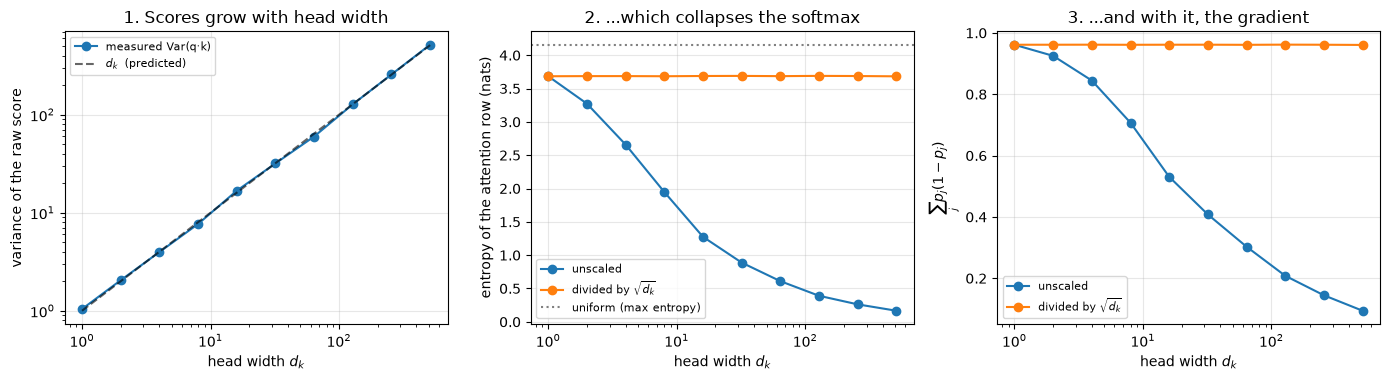

At d_k = 512, unscaled: entropy 0.1661 nats (uniform would be 4.16), gradient scale 9.42e-02
At d_k = 512, scaled  : entropy 3.6834 nats, gradient scale 9.61e-01

-> scaling preserves 10x more gradient signal at this width.


In [6]:
d_ks = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
N_PAIRS = 4096

measured_var, ent_raw, ent_scaled, grad_raw, grad_scaled = [], [], [], [], []

for d in d_ks:
    q = torch.randn(N_PAIRS, d)
    k = torch.randn(N_PAIRS, d)

    # --- claim 1: Var(q·k) = d_k
    dots = (q * k).sum(dim=-1)
    measured_var.append(dots.var().item())

    # --- claims 2 and 3: what that does to a softmax row of 64 scores
    scores = torch.randn(512, 64) * math.sqrt(d)      # a row with std sqrt(d), as derived
    for s, ent, grad in ((scores, ent_raw, grad_raw),
                         (scores / math.sqrt(d), ent_scaled, grad_scaled)):
        p = F.softmax(s, dim=-1)
        ent.append(-(p * torch.log(p + 1e-12)).sum(-1).mean().item())   # nats
        grad.append((p * (1 - p)).sum(-1).mean().item())                # softmax Jacobian scale

fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))

axes[0].loglog(d_ks, measured_var, "o-", label="measured Var(q·k)")
axes[0].loglog(d_ks, d_ks, "k--", alpha=0.6, label=r"$d_k$  (predicted)")
axes[0].set_title("1. Scores grow with head width")
axes[0].set_ylabel("variance of the raw score")

axes[1].semilogx(d_ks, ent_raw, "o-", label="unscaled")
axes[1].semilogx(d_ks, ent_scaled, "o-", label=r"divided by $\sqrt{d_k}$")
axes[1].axhline(math.log(64), color="gray", ls=":", label="uniform (max entropy)")
axes[1].set_title("2. ...which collapses the softmax")
axes[1].set_ylabel("entropy of the attention row (nats)")

axes[2].semilogx(d_ks, grad_raw, "o-", label="unscaled")
axes[2].semilogx(d_ks, grad_scaled, "o-", label=r"divided by $\sqrt{d_k}$")
axes[2].set_title("3. ...and with it, the gradient")
axes[2].set_ylabel(r"$\sum_j p_j(1-p_j)$")

for ax in axes:
    ax.set_xlabel(r"head width $d_k$")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"At d_k = 512, unscaled: entropy {ent_raw[-1]:.4f} nats "
      f"(uniform would be {math.log(64):.2f}), gradient scale {grad_raw[-1]:.2e}")
print(f"At d_k = 512, scaled  : entropy {ent_scaled[-1]:.4f} nats, "
      f"gradient scale {grad_scaled[-1]:.2e}")
print(f"\n-> scaling preserves {grad_scaled[-1] / grad_raw[-1]:.0f}x more gradient signal at this width.")

The middle panel is the one to remember. Without scaling, an attention row at
$d_k = 512$ carries **about 0.17 nats** of entropy against a possible 4.16,
having committed almost all its weight to a single token before training has
taught it anything, and the right panel shows the gradient available to fix
that mistake is roughly **10× smaller** than in the scaled case. Both gaps keep
widening with $d_k$, and production models run $d_k = 64$ to $128$ per head
with dozens of heads.

$\sqrt{d_k}$ is not a tuning constant. It is the exact factor that makes the
layer's behaviour independent of its width.

## 3.3 Steps 3 and 4: normalize, then average

🧠 **The intuition.** Softmax each row so it becomes a set of non-negative
weights summing to 1, so row $i$ is now a genuine *distribution* over where
token $i$ is looking. Then multiply by $V$: each token's output is a **weighted
average of every token's value vector**, weighted by relevance.

That is the payoff. The output at position $i$ is no longer about token $i$
alone; it is a blend of the whole sequence, mixed according to what token $i$
was looking for.

📐 **The math**, all four steps in one line:

$$ \boxed{\;\text{Attention}(Q, K, V) = \underbrace{\text{softmax}\!\left(\frac{\overbrace{Q K^\top}^{\text{score}}}{\sqrt{d_k}}\right)}_{A \;\in\; \mathbb{R}^{n \times n},\; \text{rows sum to } 1} V \;\in\; \mathbb{R}^{n \times d_v}\;} $$

💻 **The code.** The whole mechanism, written out with no abbreviations.


In [7]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    '''The one equation. Q,K,V: (..., n, d). Returns (output, attention weights).'''
    d_k = Q.shape[-1]

    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)      # (..., n, n)

    if mask is not None:                                    # Module 5
        scores = scores.masked_fill(mask == 0, float("-inf"))

    A = F.softmax(scores, dim=-1)                           # rows now sum to 1
    return A @ V, A                                         # (..., n, d_v), (..., n, n)


out, A = scaled_dot_product_attention(Q, K, V)

print("output:", tuple(out.shape), " (same shape as V: attention preserves sequence length)")
print("weights:", tuple(A.shape))
print("every row sums to 1:", torch.allclose(A.sum(-1), torch.ones(n)))
print(f"\nrow for token '{tokens[0]}': {A[0].detach().numpy().round(3)}")

output: (16, 32)  (same shape as V: attention preserves sequence length)
weights: (16, 16)
every row sums to 1: True

row for token 'the': [0.07  0.041 0.033 0.09  0.026 0.07  0.03  0.031 0.054 0.059 0.056 0.036
 0.047 0.088 0.091 0.177]


**Check it against PyTorch's own implementation.** `torch` ships a fused
version of this exact function (`F.scaled_dot_product_attention`, which
dispatches to FlashAttention on supported GPUs). If our from-scratch version is
correct, the two must agree to floating-point precision.

In [8]:
reference = F.scaled_dot_product_attention(Q, K, V)     # torch's fused kernel

max_diff = (out - reference).abs().max().item()
print(f"max absolute difference vs torch's fused kernel: {max_diff:.2e}")
assert max_diff < 1e-5, "our implementation disagrees with torch"
print("✓ identical: the equation above really is all there is to it")
print("\n(We keep our version for the rest of this notebook because it returns the")
print(" attention weights A. The fused kernel never materialises A, which is exactly")
print(" how FlashAttention saves memory, and why you cannot plot from it.)")

max absolute difference vs torch's fused kernel: 8.94e-08
✓ identical: the equation above really is all there is to it

(We keep our version for the rest of this notebook because it returns the
 attention weights A. The fused kernel never materialises A, which is exactly
 how FlashAttention saves memory, and why you cannot plot from it.)


---
# Module 4 — What Does Attention Actually Attend To?

🧠 **The intuition.** So far $W_Q$, $W_K$ and $W_V$ are random, so the
attention map is meaningless, a picture of noise. Attention patterns are
*learned*: they are a property of a trained model rather than of the mechanism.
So let us train one.

The task: IMDB sentiment. The model is deliberately minimal: an embedding
table, **one** attention layer with **one** head, mean-pooling, and a linear
classifier. No multi-head, no feed-forward network, no residuals, no
normalization. Those all arrive in Chapter 10. What we want to see here is
whether a single attention layer, given nothing but a training signal,
discovers that some words matter more than others.

💻 **The code.** First, tokenize a subset to fixed length.


In [9]:
MAX_LEN = 128          # <- knob: tokens per review (truncate/pad). Cost grows as MAX_LEN²
N_TRAIN = 20_000       # <- knob: up to 25_000
N_TEST = 5_000

def encode(split, n):
    ds = split.shuffle(seed=42).select(range(n))
    # datasets>=4 returns a lazy Column from ds["text"]; the tokenizer wants a real list
    enc = tokenizer(list(ds["text"]), truncation=True, max_length=MAX_LEN,
                    padding="max_length", return_tensors="pt")
    return enc["input_ids"], enc["attention_mask"], torch.tensor(list(ds["label"]))

train_ids, train_mask, train_y = encode(imdb["train"], N_TRAIN)
test_ids, test_mask, test_y = encode(imdb["test"], N_TEST)

print("train:", tuple(train_ids.shape), "| test:", tuple(test_ids.shape))
print("label balance (train):", train_y.float().mean().item(), "(0.5 = balanced)")
print("\nfirst review, first 20 tokens:")
print(" ", tokenizer.convert_ids_to_tokens(train_ids[0][:20]))
print("padding mask tells us which positions are real:", train_mask[0][:20].tolist())

train: (20000, 128) | test: (5000, 128)
label balance (train): 0.4977000057697296 (0.5 = balanced)

first review, first 20 tokens:
  ['[CLS]', 'there', 'is', 'no', 'relation', 'at', 'all', 'between', 'fort', '##ier', 'and', 'profile', '##r', 'but', 'the', 'fact', 'that', 'both', 'are', 'police']
padding mask tells us which positions are real: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


📐 **A note on the padding mask.** Reviews have different lengths, so short ones
are padded with `[PAD]` to reach `MAX_LEN`. Those positions carry no meaning,
and if we let real tokens attend to them the model would average in garbage. The
`attention_mask` marks the real positions with 1, and we will feed it straight
into the `mask` argument of the function we wrote in 3.3. Module 5 shows what
that does to the score matrix.

💻 **The code.** The model, in 30 lines, every one of them something you
have already seen.


In [10]:
class SingleHeadAttentionClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=64, n_classes=2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, ids, pad_mask):
        X = self.embed(ids)                                   # (B, n, d)
        Q, K, V = self.W_Q(X), self.W_K(X), self.W_V(X)

        # (B, 1, n): every query may attend to the real (non-pad) keys only
        attn_mask = pad_mask[:, None, :]
        h, A = scaled_dot_product_attention(Q, K, V, mask=attn_mask)

        # mean-pool over real positions only
        m = pad_mask.unsqueeze(-1).float()
        pooled = (h * m).sum(1) / m.sum(1).clamp(min=1)        # (B, d)
        return self.classifier(pooled), A


model = SingleHeadAttentionClassifier(tokenizer.vocab_size).to(device)
print(model)
print(f"\nparameters: {sum(p.numel() for p in model.parameters()):,} "
      f"({sum(p.numel() for p in model.embed.parameters()):,} of them the embedding table)")

SingleHeadAttentionClassifier(
  (embed): Embedding(30522, 64)
  (W_Q): Linear(in_features=64, out_features=64, bias=False)
  (W_K): Linear(in_features=64, out_features=64, bias=False)
  (W_V): Linear(in_features=64, out_features=64, bias=False)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)

parameters: 1,965,826 (1,953,408 of them the embedding table)


💻 **The training loop.** This is the part with no Keras equivalent, so it is
worth reading closely. Four lines carry the whole thing:

```python
optimizer.zero_grad()   # torch accumulates gradients; clear last step's
loss.backward()         # autograd walks the graph and fills every .grad
optimizer.step()        # apply the update
```

That is what `model.fit()` was doing for you. Everything else below is
bookkeeping: batching, moving tensors to the GPU, and tracking accuracy.


In [11]:
EPOCHS = 6                # <- knob: test accuracy plateaus by 4-6; more epochs just overfit
BATCH = 128
LR = 1e-3                 # <- knob: 3e-3 converges in 3 epochs, then degrades faster

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
train_ds = torch.utils.data.TensorDataset(train_ids, train_mask, train_y)
loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH, shuffle=True)

@torch.no_grad()
def evaluate():
    model.eval()
    correct = 0
    for i in range(0, len(test_ids), 512):
        ids = test_ids[i:i + 512].to(device)
        msk = test_mask[i:i + 512].to(device)
        logits, _ = model(ids, msk)
        correct += (logits.argmax(-1).cpu() == test_y[i:i + 512]).sum().item()
    return correct / len(test_ids)

history = []
for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for ids, msk, y in loader:
        ids, msk, y = ids.to(device), msk.to(device), y.to(device)

        logits, _ = model(ids, msk)
        loss = F.cross_entropy(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running += loss.item() * len(y)

    acc = evaluate()
    history.append((running / N_TRAIN, acc))
    print(f"epoch {epoch + 1}/{EPOCHS}  loss {running / N_TRAIN:.4f}  test acc {acc:.4f}")

epoch 1/6  loss 0.6443  test acc 0.6830


epoch 2/6  loss 0.5009  test acc 0.7578


epoch 3/6  loss 0.4030  test acc 0.7868


epoch 4/6  loss 0.3435  test acc 0.7980


epoch 5/6  loss 0.2995  test acc 0.7948


epoch 6/6  loss 0.2573  test acc 0.7930


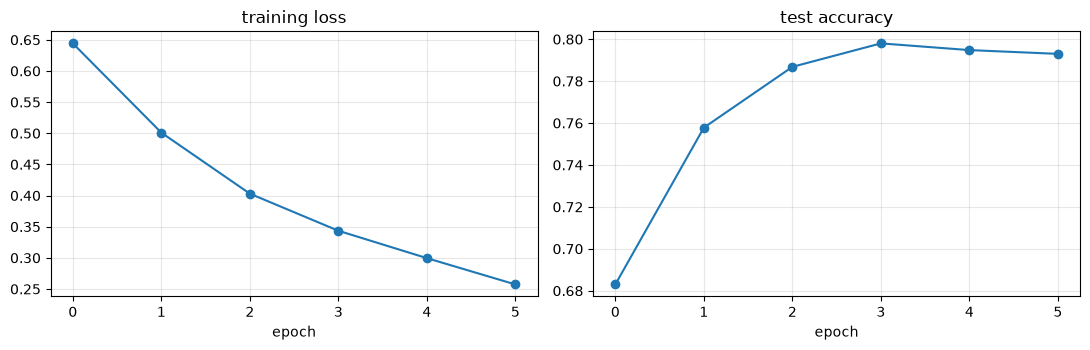

In [12]:
loss_curve, acc_curve = zip(*history)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(loss_curve, marker="o"); axes[0].set_title("training loss")
axes[1].plot(acc_curve, marker="o"); axes[1].set_title("test accuracy")
for ax in axes:
    ax.set_xlabel("epoch"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 4.1 The heatmap

🧠 **The intuition.** Now plot $A$. Row $i$, column $j$ is how much token $i$
drew from token $j$. The interesting readout for a classifier is the **column**
sums: how much total attention each token *received* from the rest of the
sequence. A token that everyone reads from is a token the model decided was
important.

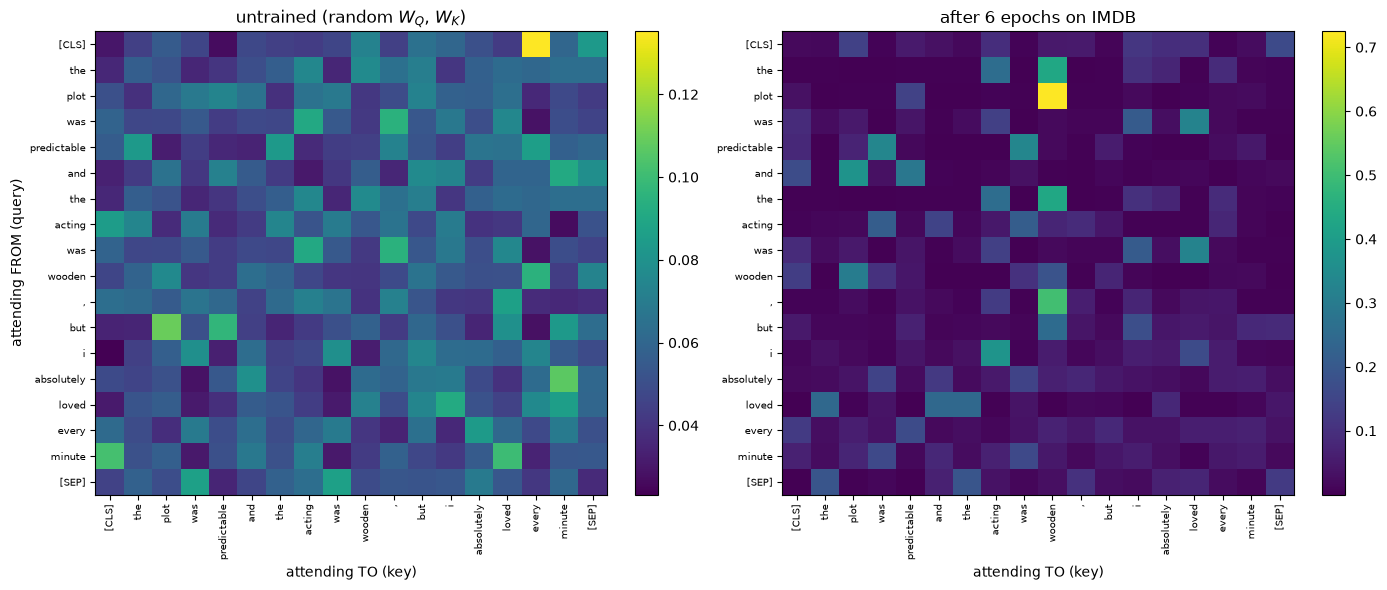

model's verdict on the probe sentence: negative


In [13]:
probe = "the plot was predictable and the acting was wooden , but i absolutely loved every minute"
enc = tokenizer(probe, return_tensors="pt", truncation=True, max_length=MAX_LEN)
p_ids, p_mask = enc["input_ids"].to(device), enc["attention_mask"].to(device)
p_tokens = tokenizer.convert_ids_to_tokens(p_ids[0])

model.eval()
with torch.no_grad():
    logits, A_trained = model(p_ids, p_mask)

# the same sentence through an untrained model, for contrast
untrained = SingleHeadAttentionClassifier(tokenizer.vocab_size).to(device)
with torch.no_grad():
    _, A_random = untrained(p_ids, p_mask)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, A_, title in ((axes[0], A_random, "untrained (random $W_Q$, $W_K$)"),
                      (axes[1], A_trained, f"after {EPOCHS} epochs on IMDB")):
    im = ax.imshow(A_[0].cpu().numpy(), cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(p_tokens)))
    ax.set_xticklabels(p_tokens, rotation=90, fontsize=7)
    ax.set_yticks(range(len(p_tokens)))
    ax.set_yticklabels(p_tokens, fontsize=7)
    ax.set_title(title)
    ax.set_xlabel("attending TO (key)")
    fig.colorbar(im, ax=ax, fraction=0.046)
axes[0].set_ylabel("attending FROM (query)")
plt.tight_layout(); plt.show()

pred = "positive" if logits.argmax().item() == 1 else "negative"
print(f"model's verdict on the probe sentence: {pred}")

The left panel is structureless, since a random projection has no reason to
prefer anything, so every token spreads its attention almost uniformly. The
right panel has visible **vertical stripes**: particular columns that many rows
read from. Those stripes are the learned part.

Which columns? Rather than eyeball it, make the claim measurable. Split
the sentence into **function words** (grammatical glue: the, was, and, of, i)
and **content words** (everything else), and compare how much attention each
group receives.


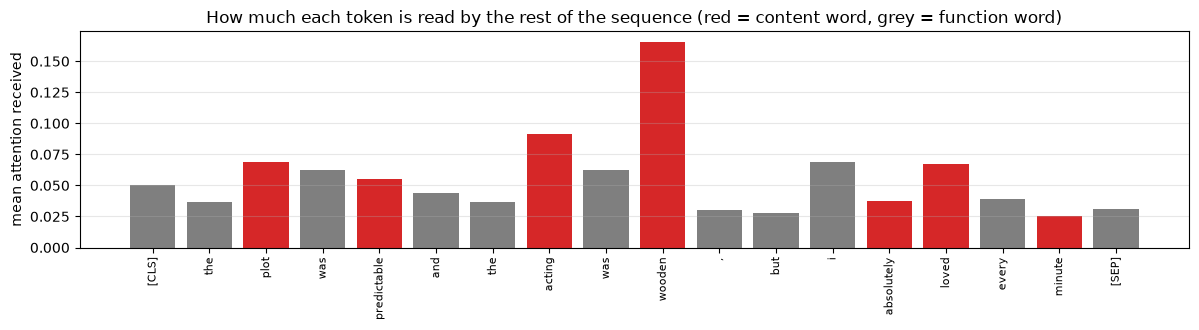

Top 6 tokens by attention received:
          wooden   0.1658   (content)
          acting   0.0912   (content)
            plot   0.0691   (content)
               i   0.0689   (function)
           loved   0.0669   (content)
             was   0.0622   (function)

mean attention received:
  content words:    0.0731
  function words:   0.0444
  uniform would be: 0.0556
-> content words attract 1.65x the attention of function words


In [14]:
received = A_trained[0].mean(dim=0).cpu().numpy()        # column means = attention received

FUNCTION_WORDS = {"the", "was", "and", "of", "i", "a", "is", ",", ".", "but",
                  "[CLS]", "[SEP]", "every", "it"}
is_content = np.array([t not in FUNCTION_WORDS for t in p_tokens])

fig, ax = plt.subplots(figsize=(12, 3.4))
ax.bar(range(len(p_tokens)), received,
       color=["tab:red" if c else "tab:gray" for c in is_content])
ax.set_xticks(range(len(p_tokens)))
ax.set_xticklabels(p_tokens, rotation=90, fontsize=8)
ax.set_ylabel("mean attention received")
ax.set_title("How much each token is read by the rest of the sequence "
             "(red = content word, grey = function word)")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

print("Top 6 tokens by attention received:")
for i in np.argsort(received)[::-1][:6]:
    kind = "content" if is_content[i] else "function"
    print(f"  {p_tokens[i]:>14}   {received[i]:.4f}   ({kind})")

c_mean, f_mean = received[is_content].mean(), received[~is_content].mean()
uniform = 1.0 / len(p_tokens)
print("\nmean attention received:")
print(f"  content words:    {c_mean:.4f}")
print(f"  function words:   {f_mean:.4f}")
print(f"  uniform would be: {uniform:.4f}")
print(f"-> content words attract {c_mean / f_mean:.2f}x the attention of function words")

## 4.2 Read the failure, too

The model attends where you would hope, favouring content words over
grammatical glue, and yet **look at the verdict it printed above: it is wrong.**
The sentence ends "absolutely loved every minute", and the model calls it
negative.

That is not a bug to fix; it is the most useful thing in this notebook. Count
the sentiment-bearing words: *predictable* and *wooden* are negative, *loved* is
positive. Two against one. A model that computes a weighted **average** over an
unordered set of tokens is doing something very close to counting, and two beats
one.

What it is missing is the ability to represent that **"but" inverts everything
before it**. That requires knowing which words came before "but" and which came
after, and our layer has **no positional information whatsoever**. Permute the
input tokens and the output permutes with them, unchanged in content. "Dog bites
man" and "man bites dog" are, to this model, the same sentence.

That single missing ingredient is the first thing Chapter 10 adds.

💻 **Do not take "permutation-equivariant" on faith either**, since it is two
lines to check.


In [15]:
perm = torch.randperm(p_ids.shape[1], device=device)

with torch.no_grad():
    logits_orig, _ = model(p_ids, p_mask)
    logits_shuf, _ = model(p_ids[:, perm], p_mask[:, perm])

print("original word order :", logits_orig.cpu().numpy().round(4))
print("shuffled word order :", logits_shuf.cpu().numpy().round(4))
print("identical:", torch.allclose(logits_orig, logits_shuf, atol=1e-4))
print("\nShuffling the sentence changes nothing. The layer sees a *set* of tokens,")
print("not a sequence. Positional encodings (Chapter 10) break this symmetry.")

original word order : [[ 4.6227 -4.7962]]
shuffled word order : [[ 4.6227 -4.7962]]


identical: True

Shuffling the sentence changes nothing. The layer sees a *set* of tokens,
not a sequence. Positional encodings (Chapter 10) break this symmetry.


**One broader caution while we are here: attention weights are not
explanations.** A substantial literature (Jain & Wallace, 2019; Wiegreffe &
Pinter, 2019) shows you can often construct very different attention maps that
yield identical predictions. A heatmap tells you where information *flowed*, not
why the model decided what it decided. Treat these plots as a window into the
mechanism, not as a justification for an output.

---
# Module 5 — Masking

🧠 **The intuition.** Attention's default is total connectivity: every position
sees every other. Masking is how you take that away selectively, and there are
two reasons to want to.

**Padding masks** handle the boring one: batched sequences have different real
lengths, and nobody should attend to filler.

**Causal masks** handle the important one. A model that generates text one
token at a time must never see the future during training. If position 5 can
attend to position 6, then predicting position 6 is trivial, since the model
reads the answer and learns nothing. So we forbid attending to any position to
the right. This single triangular matrix is the entire architectural difference
between BERT (bidirectional, sees everything, good for understanding) and GPT
(causal, sees only the past, can therefore generate).

📐 **The math.** The mask is applied to the **scores, before the softmax**, by
setting forbidden entries to $-\infty$:

$$ S'_{ij} = \begin{cases} S_{ij} & \text{if } j \text{ is visible from } i \\ -\infty & \text{otherwise} \end{cases} \qquad\Longrightarrow\qquad \text{softmax}(S')_{ij} = 0 $$

The $-\infty$ matters. Zeroing the *weights* after the softmax would break the
"rows sum to 1" property; setting the *scores* to $-\infty$ makes
$e^{-\infty} = 0$ and lets the remaining entries renormalize among themselves.
For the causal case the mask is lower-triangular, which in code is `torch.tril`.


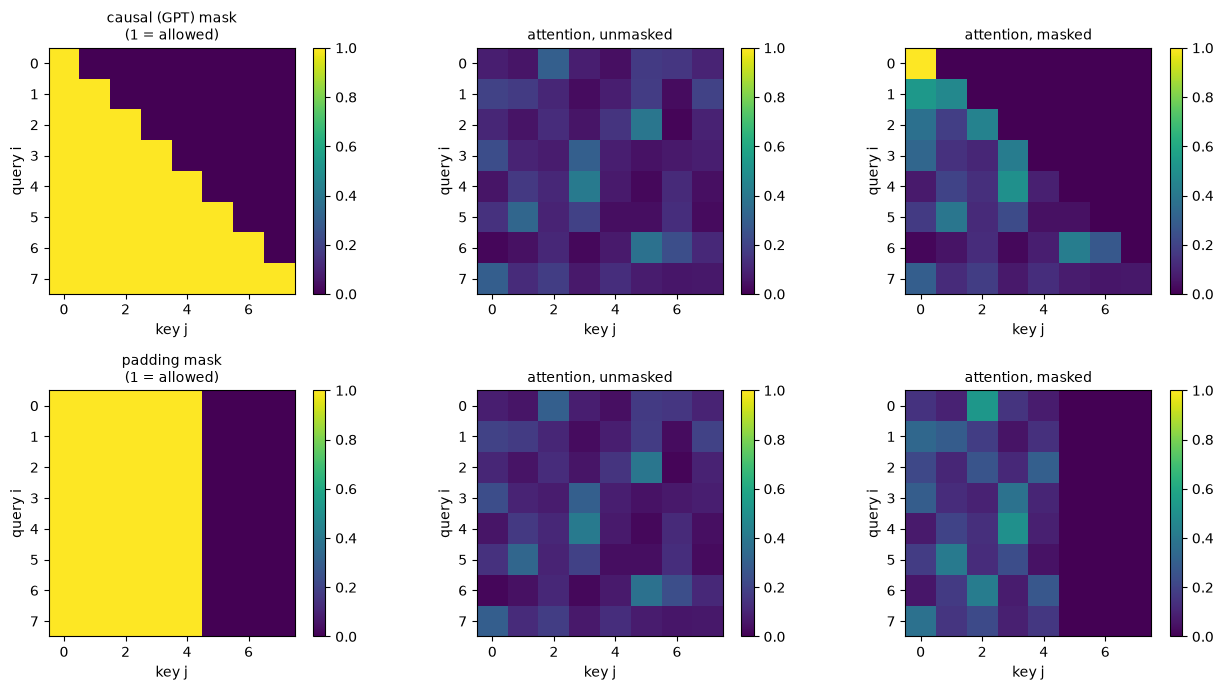

causal rows still sum to 1: True
token 0 attends only to itself: [1. 0. 0. 0. 0. 0. 0. 0.]
token 3 attends to 0..3 only  : [0.331 0.141 0.106 0.421 0.    0.    0.    0.   ]


In [16]:
n_demo = 8
causal = torch.tril(torch.ones(n_demo, n_demo))
padding = torch.ones(n_demo, n_demo)
padding[:, 5:] = 0                                    # last 3 positions are [PAD]

Qd, Kd, Vd = (torch.randn(n_demo, 16) for _ in range(3))

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for row, (mask, name) in enumerate(((causal, "causal (GPT)"), (padding, "padding"))):
    _, A_masked = scaled_dot_product_attention(Qd, Kd, Vd, mask=mask)
    _, A_open = scaled_dot_product_attention(Qd, Kd, Vd)

    for ax, mat, t in ((axes[row, 0], mask, f"{name} mask\n(1 = allowed)"),
                       (axes[row, 1], A_open, "attention, unmasked"),
                       (axes[row, 2], A_masked, "attention, masked")):
        im = ax.imshow(mat.numpy(), cmap="viridis", vmin=0, vmax=1)
        ax.set_title(t, fontsize=10)
        ax.set_xlabel("key j"); ax.set_ylabel("query i")
        fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

_, A_causal = scaled_dot_product_attention(Qd, Kd, Vd, mask=causal)
print("causal rows still sum to 1:", torch.allclose(A_causal.sum(-1), torch.ones(n_demo)))
print("token 0 attends only to itself:", A_causal[0].numpy().round(3))
print("token 3 attends to 0..3 only  :", A_causal[3].numpy().round(3))

Look at the bottom-left triangle in the masked causal plot and note that each
row **renormalizes**: token 0 has only one option, so it attends to itself with
weight 1.0. Token 3 spreads its full attention budget across positions 0–3. No
probability mass leaks to the future.

This is the mechanism behind "context window" as well. A model trained with a
causal mask over 8,192 positions has simply never been asked to renormalize over
more than 8,192 columns.

---
# Module 6 — The Bill: $O(n^2)$

🧠 **The intuition.** The score matrix $S$ has one entry for every ordered pair
of positions. Double the sequence length and you quadruple the work *and* the
memory. That single fact drives an enormous amount of practical design:

- **Why Vision Transformers use 16×16 patches instead of pixels.** A 224×224
  image is 50,176 pixels; as a sequence that is $2.5 \times 10^9$ attention
  entries per head, per layer. Cut it into 196 patches and it is 38,416, about
  65,000 times cheaper.
- **Why Stable Diffusion runs in a latent space**, and why any Transformer
  denoiser patchifies its latents before attending over them.
- **Why context windows were the headline number** in every LLM release for
  years, and why FlashAttention, sliding-window attention, and linear-attention
  variants all exist.

💻 **The code.** Measure it rather than assume it.


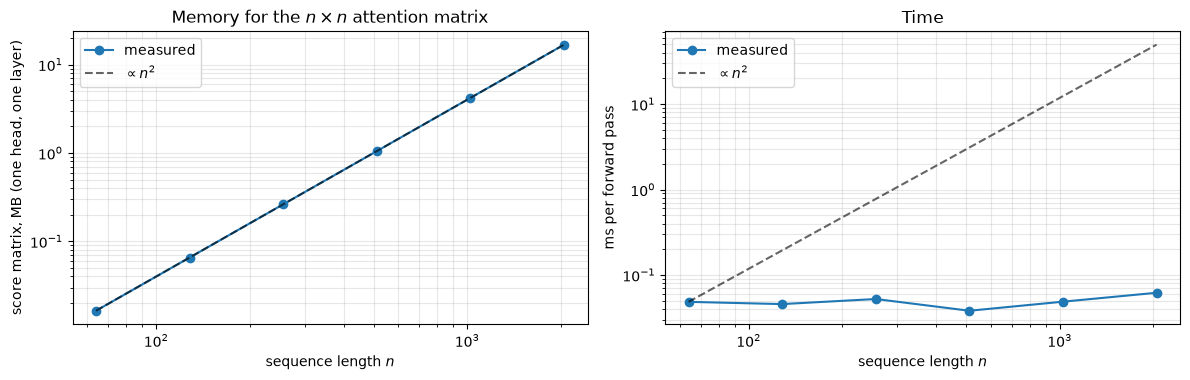

At n = 2048, one head's score matrix alone is 17 MB.
A 32-layer, 32-head model at batch 8 would need 137 GB just to hold them.

This is precisely the number FlashAttention exists to avoid: it never
materialises the full matrix, computing the softmax in tiles instead.


In [17]:
lengths = [64, 128, 256, 512, 1024, 2048]
D = 64
naive_mem, times = [], []

for L in lengths:
    q = torch.randn(1, L, D, device=device)
    naive_mem.append(L * L * 4 / 1e6)             # float32 score matrix, MB

    if device == "cuda":
        torch.cuda.synchronize()
    start = torch.cuda.Event(enable_timing=True) if device == "cuda" else None
    end = torch.cuda.Event(enable_timing=True) if device == "cuda" else None

    if device == "cuda":
        for _ in range(3):
            scaled_dot_product_attention(q, q, q)
        torch.cuda.synchronize()
        start.record()
        for _ in range(20):
            scaled_dot_product_attention(q, q, q)
        end.record(); torch.cuda.synchronize()
        times.append(start.elapsed_time(end) / 20)
    else:
        import time
        t0 = time.time()
        for _ in range(3):
            scaled_dot_product_attention(q, q, q)
        times.append((time.time() - t0) / 3 * 1000)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.9))
axes[0].loglog(lengths, naive_mem, "o-", label="measured")
axes[0].loglog(lengths, [naive_mem[0] * (L / lengths[0]) ** 2 for L in lengths],
               "k--", alpha=0.6, label=r"$\propto n^2$")
axes[0].set_ylabel("score matrix, MB (one head, one layer)")
axes[0].set_title("Memory for the $n \\times n$ attention matrix")

axes[1].loglog(lengths, times, "o-", label="measured")
axes[1].loglog(lengths, [times[0] * (L / lengths[0]) ** 2 for L in lengths],
               "k--", alpha=0.6, label=r"$\propto n^2$")
axes[1].set_ylabel("ms per forward pass")
axes[1].set_title("Time")

for ax in axes:
    ax.set_xlabel("sequence length $n$"); ax.legend(); ax.grid(True, alpha=0.3, which="both")
plt.tight_layout(); plt.show()

print(f"At n = 2048, one head's score matrix alone is {naive_mem[-1]:.0f} MB.")
print(f"A 32-layer, 32-head model at batch 8 would need "
      f"{naive_mem[-1] * 32 * 32 * 8 / 1000:.0f} GB just to hold them.")
print("\nThis is precisely the number FlashAttention exists to avoid: it never")
print("materialises the full matrix, computing the softmax in tiles instead.")

---
# Wrap-Up

| You built | The transferable lesson |
|---|---|
| $Q = XW_Q,\; K = XW_K,\; V = XW_V$ | Addressing ("who is relevant") and content ("what do they say") are separate learned projections of the same input |
| $QK^\top$ | A dot product is a similarity score; doing all pairs at once is one matmul |
| $\div \sqrt{d_k}$ | Not a hyperparameter, but the exact factor that makes softmax saturation independent of head width, measured in 3.2 |
| softmax → weighted sum of $V$ | Each output position is a learned blend of the entire sequence, path length 1 |
| Padding and causal masks | $-\infty$ before the softmax, never zeros after; the causal triangle is the whole difference between BERT and GPT |
| The $n^2$ measurement | Every practical decision downstream (patch size, latent diffusion, context length) is a response to this curve |

**What this single layer still cannot do**, and what Chapter 10 fixes:

1. **It has no idea what order the words are in.** Permute the input tokens and
   the output permutes identically, because attention is
   *permutation-equivariant*. "Dog bites man" and "man bites dog" are currently
   the same input.
   → **Positional encodings**.
2. **One head can only model one kind of relationship.** The single softmax has
   to serve as syntax parser, coreference resolver, and topic tracker
   simultaneously, and it will average those roles into mush.
   → **Multi-head attention**.
3. **It is entirely linear in $V$.** Every output is a weighted *average* of
   value vectors; stack two such layers and you still have a (data-dependent)
   linear map. There is no elementwise nonlinearity anywhere in Module 3.
   → **The position-wise feed-forward network**, which is where most of a
   Transformer's parameters actually live.
4. **It will not train at depth.** Twelve of these stacked would suffer exactly
   the degradation you diagnosed in Chapter 3.
   → **Residual connections and LayerNorm**.

Chapter 10 adds all four and assembles the result into the Transformer encoder
block, the unit that, repeated, is BERT, GPT, ViT, and the DiT.
